# F3 – Week 06 Black-Box Optimisation (3D)

Structure: **Config → Load → Surrogate → Acquisition → Diagnostics → Output**

Goal: maximise transformed objective **y = - (side effects)** (higher is better).


In [1]:
# =========================
# 0) CONFIG
# =========================
import os
import numpy as np

# Repo-relative paths (as requested)
INPUTS_PATH = "data/F3/initial_inputs.npy"
OUTPUTS_PATH = "data/F3/initial_outputs.npy"

# Fallback for this notebook environment (when files are mounted elsewhere)
_FALLBACK_INPUTS = "/mnt/data/initial_inputs.npy"
_FALLBACK_OUTPUTS = "/mnt/data/initial_outputs.npy"

def _resolve(path, fallback):
    return path if os.path.exists(path) else fallback

INPUTS_PATH_RESOLVED = _resolve(INPUTS_PATH, _FALLBACK_INPUTS)
OUTPUTS_PATH_RESOLVED = _resolve(OUTPUTS_PATH, _FALLBACK_OUTPUTS)

RANDOM_SEED = 0

# Candidate generation
N_GLOBAL = 30000     # random global candidates in [0,1]^3
N_LOCAL  = 4000      # local perturbations around current best
LOCAL_SIGMA = 0.06   # local perturbation std (in original [0,1] space)

# Expected Improvement settings
XI = 0.01            # exploration bias (higher => more exploration)
TAU_DIST = 0.05      # distance-penalty scale (higher => weaker penalty)

print("Inputs:", INPUTS_PATH_RESOLVED)
print("Outputs:", OUTPUTS_PATH_RESOLVED)


Inputs: data/F3/initial_inputs.npy
Outputs: data/F3/initial_outputs.npy


In [2]:
# =========================
# 1) LOAD
# =========================
X = np.load(INPUTS_PATH_RESOLVED)   # shape (n, 3)
y = np.load(OUTPUTS_PATH_RESOLVED)  # shape (n,)

assert X.ndim == 2 and X.shape[1] == 3, f"Expected X to be (n,3), got {X.shape}"
assert y.ndim == 1 and len(y) == len(X), f"Expected y to be (n,), got {y.shape}"

print("Dataset size:", X.shape[0])
print("y stats: min/mean/max =", float(y.min()), float(y.mean()), float(y.max()))
print("Best observed x:", X[y.argmax()], " best y:", float(y.max()))


Dataset size: 20
y stats: min/mean/max = -0.4391525756952428 -0.1270473369384703 -0.034149335922067627
Best observed x: [0.983434 0.915074 0.398418]  best y: -0.034149335922067627


In [3]:
# =========================
# 2) SURROGATE
# =========================
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Scale X and y for GP numerical stability
x_scaler = StandardScaler()
y_scaler = StandardScaler()
Xs = x_scaler.fit_transform(X)
ys = y_scaler.fit_transform(y.reshape(-1,1)).ravel()

# Matérn 5/2 with ARD + noise
kernel = (
    C(1.0, (1e-2, 1e2))
    * Matern(length_scale=np.ones(3), length_scale_bounds=(1e-1, 1e1), nu=2.5)
    + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-2))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,               # nugget for stability
    normalize_y=False,
    n_restarts_optimizer=0,   # keep fast for weekly iterations
    random_state=RANDOM_SEED,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gp.fit(Xs, ys)

print("Fitted GP kernel:", gp.kernel_)

# Auxiliary uncertainty / interpretability models
rf = RandomForestRegressor(
    n_estimators=150,
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
rf.fit(X, y)

gbm_ensemble = []
for seed in range(2):
    m = HistGradientBoostingRegressor(
        learning_rate=0.12,
        max_depth=3,
        max_iter=80,
        early_stopping=True,
        random_state=seed,
    )
    m.fit(X, y)
    gbm_ensemble.append(m)

print("RF feature importances:", rf.feature_importances_)


Fitted GP kernel: 1.08**2 * Matern(length_scale=[9.53, 10, 0.263], nu=2.5) + WhiteKernel(noise_level=0.00934)
RF feature importances: [0.10297383 0.19953312 0.69749305]


In [4]:
# =========================
# 3) ACQUISITION
# =========================
from scipy.stats import norm

rng = np.random.default_rng(RANDOM_SEED)

# Candidate pool: global + local around current best
x_best = X[y.argmax()]
cand_global = rng.random((N_GLOBAL, 3))
cand_local  = np.clip(x_best + rng.normal(0, LOCAL_SIGMA, size=(N_LOCAL, 3)), 0.0, 1.0)
CAND = np.vstack([cand_global, cand_local])

# GP predictions (convert back to original y space)
CANDs = x_scaler.transform(CAND)
mu_s, std_s = gp.predict(CANDs, return_std=True)
mu  = y_scaler.inverse_transform(mu_s.reshape(-1,1)).ravel()
std = std_s * y_scaler.scale_[0]

y_best = float(y.max())
imp = mu - y_best - XI
Z = np.divide(imp, std, out=np.zeros_like(imp), where=std > 1e-12)

ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
ei = np.maximum(ei, 0.0)

# Distance penalty: down-weight points too close to existing samples
def min_dist_to_X(cand, X, chunk=6000):
    mins = []
    for i in range(0, cand.shape[0], chunk):
        c = cand[i:i+chunk]
        d2 = ((c[:,None,:] - X[None,:,:])**2).sum(axis=2)
        mins.append(np.sqrt(d2.min(axis=1)))
    return np.concatenate(mins)

min_d = min_dist_to_X(CAND, X)
pen = 1.0 - np.exp(-min_d / TAU_DIST)

score = ei * pen
best_idx = int(np.argmax(score))

x_next = CAND[best_idx]
pred_mu = float(mu[best_idx])
pred_sd = float(std[best_idx])
pred_min_dist = float(min_d[best_idx])

print("Proposed next x (Week 06 submission):", x_next)
print("GP predicted mean:", pred_mu, "  predicted sd:", pred_sd)
print("Min distance to existing samples:", pred_min_dist)


Proposed next x (Week 06 submission): [0.85676589 0.99624241 0.50410992]
GP predicted mean: -0.050696318241251426   predicted sd: 0.05959012913089748
Min distance to existing samples: 0.18385837929904528


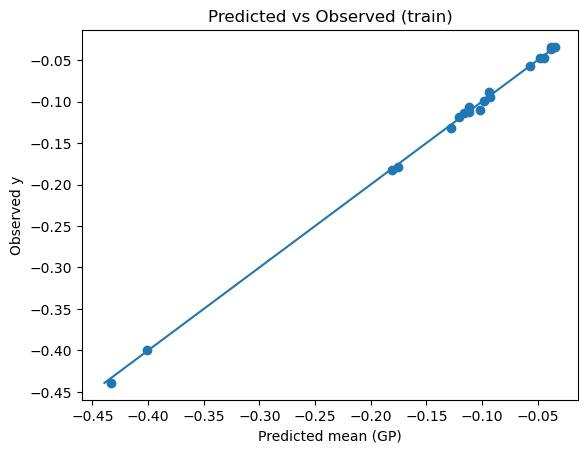

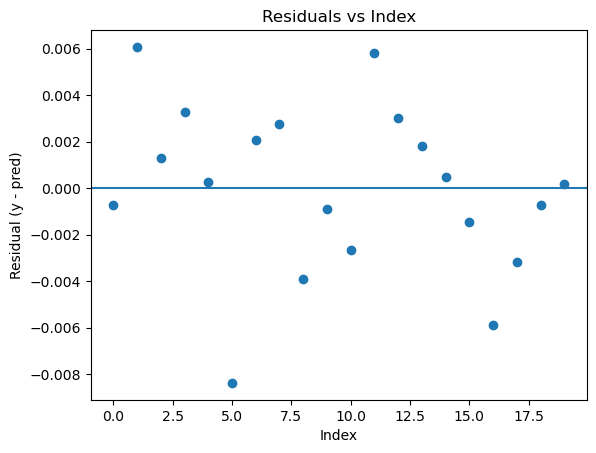

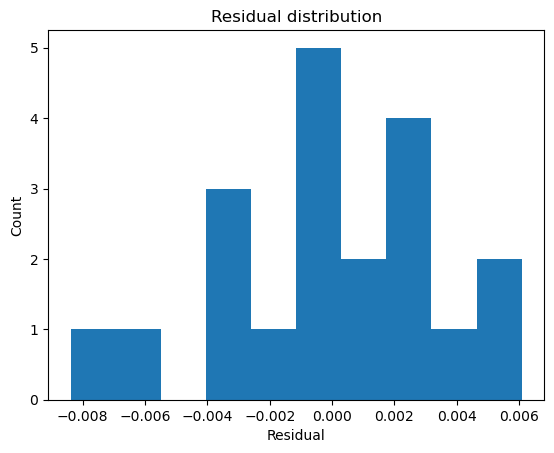

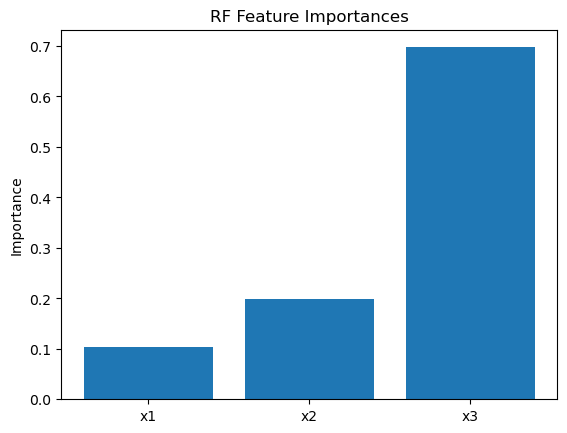

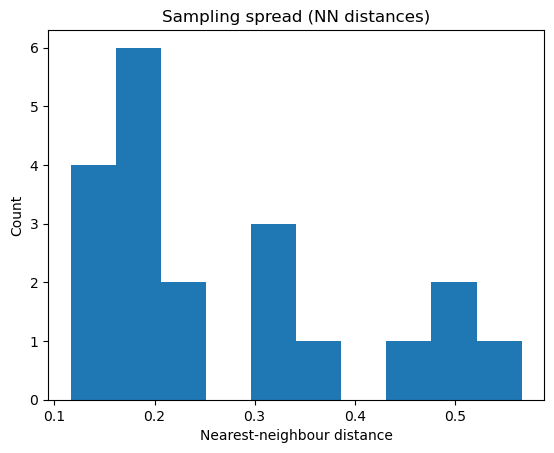

NN distance: min/mean/max = 0.11626815403249999 0.2746917370393608 0.5665979076180379
Current best x: [0.983434 0.915074 0.398418]  best y: -0.034149335922067627
Proposed x_next: [0.85676589 0.99624241 0.50410992]


In [5]:
# =========================
# 4) DIAGNOSTICS
# =========================
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Predicted vs observed (in-sample) for quick sanity check
mu_train_s, sd_train_s = gp.predict(Xs, return_std=True)
mu_train = y_scaler.inverse_transform(mu_train_s.reshape(-1,1)).ravel()
resid = y - mu_train

plt.figure()
plt.scatter(mu_train, y)
lims = [min(mu_train.min(), y.min()), max(mu_train.max(), y.max())]
plt.plot(lims, lims)
plt.xlabel("Predicted mean (GP)")
plt.ylabel("Observed y")
plt.title("Predicted vs Observed (train)")
plt.show()

plt.figure()
plt.scatter(range(len(resid)), resid)
plt.axhline(0)
plt.xlabel("Index")
plt.ylabel("Residual (y - pred)")
plt.title("Residuals vs Index")
plt.show()

plt.figure()
plt.hist(resid, bins=10)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.show()

# Feature importance (RF)
plt.figure()
plt.bar(["x1","x2","x3"], rf.feature_importances_)
plt.ylabel("Importance")
plt.title("RF Feature Importances")
plt.show()

# Check spatial spread: nearest-neighbour distances
nn = NearestNeighbors(n_neighbors=2).fit(X)
dists, _ = nn.kneighbors(X)
nn_dist = dists[:,1]

plt.figure()
plt.hist(nn_dist, bins=10)
plt.xlabel("Nearest-neighbour distance")
plt.ylabel("Count")
plt.title("Sampling spread (NN distances)")
plt.show()

print("NN distance: min/mean/max =", float(nn_dist.min()), float(nn_dist.mean()), float(nn_dist.max()))

# Quick 'are we stuck?' check: compare candidate vs current best region
print("Current best x:", x_best, " best y:", y_best)
print("Proposed x_next:", x_next)


In [6]:
# =========================
# 5) OUTPUT
# =========================
# One-line submission format (copy/paste)
print(f"{x_next[0]:.8f} {x_next[1]:.8f} {x_next[2]:.8f}")


0.85676589 0.99624241 0.50410992
